In [4]:
import torch
import torchvision
import torchvision.transforms as transforms

# Dönüşümleri tanımla
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# İndirmeyi başlat (num_workers=0 ekledik)
if __name__ == '__main__':
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=0)

    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, num_workers=0)

    classes = ('Uçak', 'Otomobil', 'Kuş', 'Kedi', 'Geyik', 'Köpek', 'Kurbağa', 'At', 'Gemi', 'Kamyon')
    print("Veri indirme işlemi tamamlandı veya zaten mevcut!")

Veri indirme işlemi tamamlandı veya zaten mevcut!


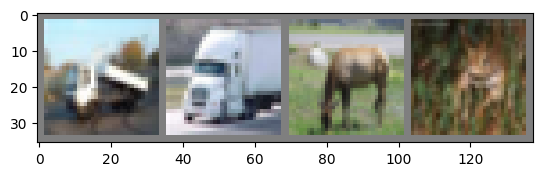

Gerçek Etiketler:  Kamyon Kamyon Geyik Kurbağa


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # Normalize işlemini geri al
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # [C, H, W] -> [H, W, C]
    plt.show()

# Rastgele bir paket resim al
dataiter = iter(trainloader)
images, labels = next(dataiter)

# İlk 4 tanesini göster
imshow(torchvision.utils.make_grid(images[:4]))
print('Gerçek Etiketler: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NesneTaniyici(nn.Module):
    def __init__(self):
        super(NesneTaniyici, self).__init__()
        # 1. Blok: 32 filtreli ilk evrişim katmanı
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # 2. Blok: 64 filtreli ikinci evrişim katmanı
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # Boyutu yarıya indirir (32x32 -> 16x16)
        
        # 3. Blok: 128 filtreli üçüncü evrişim katmanı
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        
        # Tam Bağlantılı Katmanlar (Sınıflandırma kısmı)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        # 1. ve 2. katmanlar + Pooling
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        
        # 3. katman + Pooling (16x16 -> 8x8)
        x = self.pool(F.relu(self.bn2(self.conv3(x))))
        
        # Karar aşaması
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Modeli cihazımıza (GPU/CPU) yerleştiriyoruz
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = NesneTaniyici().to(device)
print(f"Model şu an {device} üzerinde tanımlandı.")

Model şu an cpu üzerinde tanımlandı.


In [7]:
import torch.optim as optim

# Kayıp fonksiyonu (Çok sınıflı sınıflandırma için standart)
criterion = nn.CrossEntropyLoss()

# Optimizer (Adam, öğrenme hızını kendi ayarlayan akıllı bir motordur)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Kayıp fonksiyonu ve optimizer hazır.")

Kayıp fonksiyonu ve optimizer hazır.


In [9]:
epochs = 5  # Toplam 5 tur döneceğiz

print(f"Eğitim başlıyor... Cihaz: {device}")

for epoch in range(epochs):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # 1. Verileri al ve cihaza (GPU/CPU) gönder
        inputs, labels = data[0].to(device), data[1].to(device)

        # 2. Gradyanları sıfırla
        optimizer.zero_grad()

        # 3. İleri besleme (Tahmin yap)
        outputs = model(inputs)
        
        # 4. Hatayı hesapla
        loss = criterion(outputs, labels)
        
        # 5. Geri yayılım (Hatayı geriye doğru dağıt)
        loss.backward()
        
        # 6. Ağırlıkları güncelle (Öğrenme adımı)
        optimizer.step()

        # İstatistikleri biriktir ve yazdır
        running_loss += loss.item()
        if i % 200 == 199:    # Her 200 pakette bir çıktı ver
            print(f'Epoch [{epoch + 1}/{epochs}], Adım [{i + 1:5d}], Kayıp (Loss): {running_loss / 200:.3f}')
            running_loss = 0.0

print('--- Eğitim Tamamlandı! ---')

Eğitim başlıyor... Cihaz: cpu
Epoch [1/5], Adım [  200], Kayıp (Loss): 1.197
Epoch [1/5], Adım [  400], Kayıp (Loss): 1.135
Epoch [1/5], Adım [  600], Kayıp (Loss): 1.044
Epoch [2/5], Adım [  200], Kayıp (Loss): 0.942
Epoch [2/5], Adım [  400], Kayıp (Loss): 0.928
Epoch [2/5], Adım [  600], Kayıp (Loss): 0.900
Epoch [3/5], Adım [  200], Kayıp (Loss): 0.801
Epoch [3/5], Adım [  400], Kayıp (Loss): 0.809
Epoch [3/5], Adım [  600], Kayıp (Loss): 0.807
Epoch [4/5], Adım [  200], Kayıp (Loss): 0.725
Epoch [4/5], Adım [  400], Kayıp (Loss): 0.713
Epoch [4/5], Adım [  600], Kayıp (Loss): 0.715
Epoch [5/5], Adım [  200], Kayıp (Loss): 0.637
Epoch [5/5], Adım [  400], Kayıp (Loss): 0.653
Epoch [5/5], Adım [  600], Kayıp (Loss): 0.654
--- Eğitim Tamamlandı! ---


In [ ]:
import torch
PATH = './cifar_net_v1.pth'
torch.save(model.state_dict(), PATH)
print(f"Model başarıyla {PATH} olarak kaydedildi. Artık güvendeyiz!")

Model başarıyla ./cifar_net_v1.pth olarak kaydedildi. Artık güvendeyiz!


C:\Users\PC\AppData\Roaming\Python\Python311\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


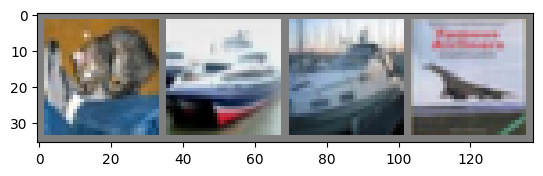

Gerçek Etiketler:  Kedi  Gemi  Gemi  Uçak 


NameError: name 'model' is not defined

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Eğer testloader tanımlı değilse tekrar tanımlayalım
if 'testloader' not in locals():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)
    classes = ('Uçak', 'Otomobil', 'Kuş', 'Kedi', 'Geyik', 'Köpek', 'Kurbağa', 'At', 'Gemi', 'Kamyon')

# 2. Test setinden bir paket (batch) resim alalım
dataiter = iter(testloader)
images, labels = next(dataiter)

# 3. Görselleştirme fonksiyonu
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# 4. Resimleri ve gerçek etiketleri göster
imshow(torchvision.utils.make_grid(images[:4]))
print('Gerçek Etiketler: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

# 5. Modelin Tahmini
model.eval()
with torch.no_grad():
    # Verileri modelin olduğu cihaza (CPU) gönderiyoruz
    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

print('Modelin Tahmini: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))

Model yeniden oluşturuldu.


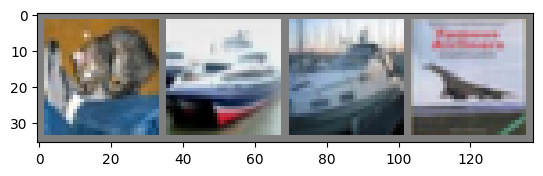

Gerçekler:  Kedi  Gemi  Gemi  Uçak 
Tahminler:  Uçak  Gemi  Uçak  Gemi 


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Mimariyi tekrar hatırlatalım (NameError: model hatasını çözer)
class NesneTaniyici(nn.Module):
    def __init__(self):
        super(NesneTaniyici, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.bn2(self.conv3(x))))
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 2. Cihazı ve Modeli oluştur
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ÖNEMLİ: Eğer model değişkeni yoksa oluştur
if 'model' not in locals():
    model = NesneTaniyici().to(device)
    print("Model yeniden oluşturuldu.")

# 3. Test verilerini hazırla
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False)
classes = ('Uçak', 'Otomobil', 'Kuş', 'Kedi', 'Geyik', 'Köpek', 'Kurbağa', 'At', 'Gemi', 'Kamyon')

# 4. Tahmin Yap ve Görselleştir
dataiter = iter(testloader)
images, labels = next(dataiter)

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(torchvision.utils.make_grid(images))
print('Gerçekler: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

model.eval()
with torch.no_grad():
    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

print('Tahminler: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))